# FASE 1 — Modelagem e Avaliação

**Datasets utilizados:** ambos os arquivos extraídos do mesmo [dataset Kaggle PCOS](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos), explorados individualmente nos notebooks de EDA:
- `PCOS_data_without_infertility.xlsx` — dataset principal (541 pacientes, 42 features após limpeza)
- `PCOS_infertility.csv` — subconjunto hormonal explorado em `01_eda_infertility.ipynb`; suas colunas (`I beta-HCG`, `II beta-HCG`, `AMH`) já estão incorporadas no Excel e entram na modelagem através dele

**Objetivo:** treinar e avaliar modelos de classificação (KNN, Regressão Logística e Árvore de Decisão) para diagnóstico de PCOS, com análise de correlação, métricas de desempenho, interpretabilidade via SHAP e discussão crítica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors  import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap

## 1. Carregamento e pré-processamento

Repete o tratamento já feito no notebook de EDA (remoção de colunas irrelevantes, conversão de tipos, imputação de nulos) para que este notebook seja autocontido.

In [2]:
# Carrega o dataset principal
df = pd.read_excel('../data/PCOS_data_without_infertility.xlsx', sheet_name='Full_new')
print(f'{df.shape[0]} linhas, {df.shape[1]} colunas')

# Remove colunas de identificação e coluna vazia
cols_to_drop = ['Sl. No', 'Patient File No.', 'Unnamed: 44']
cols_exist = [c for c in cols_to_drop if c in df.columns]
if cols_exist:
    df = df.drop(columns=cols_exist)
    print(f'Colunas removidas: {cols_exist}')

# Converte colunas object/str para numérico
for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f'Coluna "{col}" convertida para numérico.')

# Imputa valores nulos com a mediana
colunas_nulas = df.columns[df.isnull().any()].tolist()
if colunas_nulas:
    imputer = SimpleImputer(strategy='median')
    df[colunas_nulas] = imputer.fit_transform(df[colunas_nulas])
    print(f'Colunas imputadas: {colunas_nulas}')

print(f'\nDataset final: {df.shape[0]} linhas, {df.shape[1]} colunas')
print(f'Valores nulos: {df.isnull().sum().sum()}')

541 linhas, 45 colunas
Colunas removidas: ['Sl. No', 'Patient File No.', 'Unnamed: 44']
Coluna "II    beta-HCG(mIU/mL)" convertida para numérico.
Coluna "AMH(ng/mL)" convertida para numérico.
Colunas imputadas: ['Marraige Status (Yrs)', 'II    beta-HCG(mIU/mL)', 'AMH(ng/mL)', 'Fast food (Y/N)']

Dataset final: 541 linhas, 42 colunas
Valores nulos: 0


## 2. Análise de correlação

### 2.1 Correlação das features com a variável target

Identifica quais features têm maior correlação (positiva ou negativa) com o diagnóstico de PCOS.

In [3]:
# Correlação de cada feature com a target, ordenada por valor absoluto
corr_target = df.corr(numeric_only=True)['PCOS (Y/N)'].drop('PCOS (Y/N)')
corr_target_sorted = corr_target.abs().sort_values(ascending=False)

print('Top 15 features mais correlacionadas com PCOS (Y/N):\n')
for feat in corr_target_sorted.head(15).index:
    print(f'  {feat:40s}  {corr_target[feat]:+.3f}')

Top 15 features mais correlacionadas com PCOS (Y/N):

  Follicle No. (R)                          +0.648
  Follicle No. (L)                          +0.603
  Skin darkening (Y/N)                      +0.476
  hair growth(Y/N)                          +0.465
  Weight gain(Y/N)                          +0.441
  Cycle(R/I)                                +0.402
  Fast food (Y/N)                           +0.376
  Pimples(Y/N)                              +0.286
  AMH(ng/mL)                                +0.264
  Weight (Kg)                               +0.212
  BMI                                       +0.200
  Cycle length(days)                        -0.178
  Hair loss(Y/N)                            +0.173
   Age (yrs)                                -0.169
  Waist(inch)                               +0.165


### 2.2 Matriz de correlação com heatmap

Visualização completa da correlação entre todas as features para identificar padrões e agrupamentos.

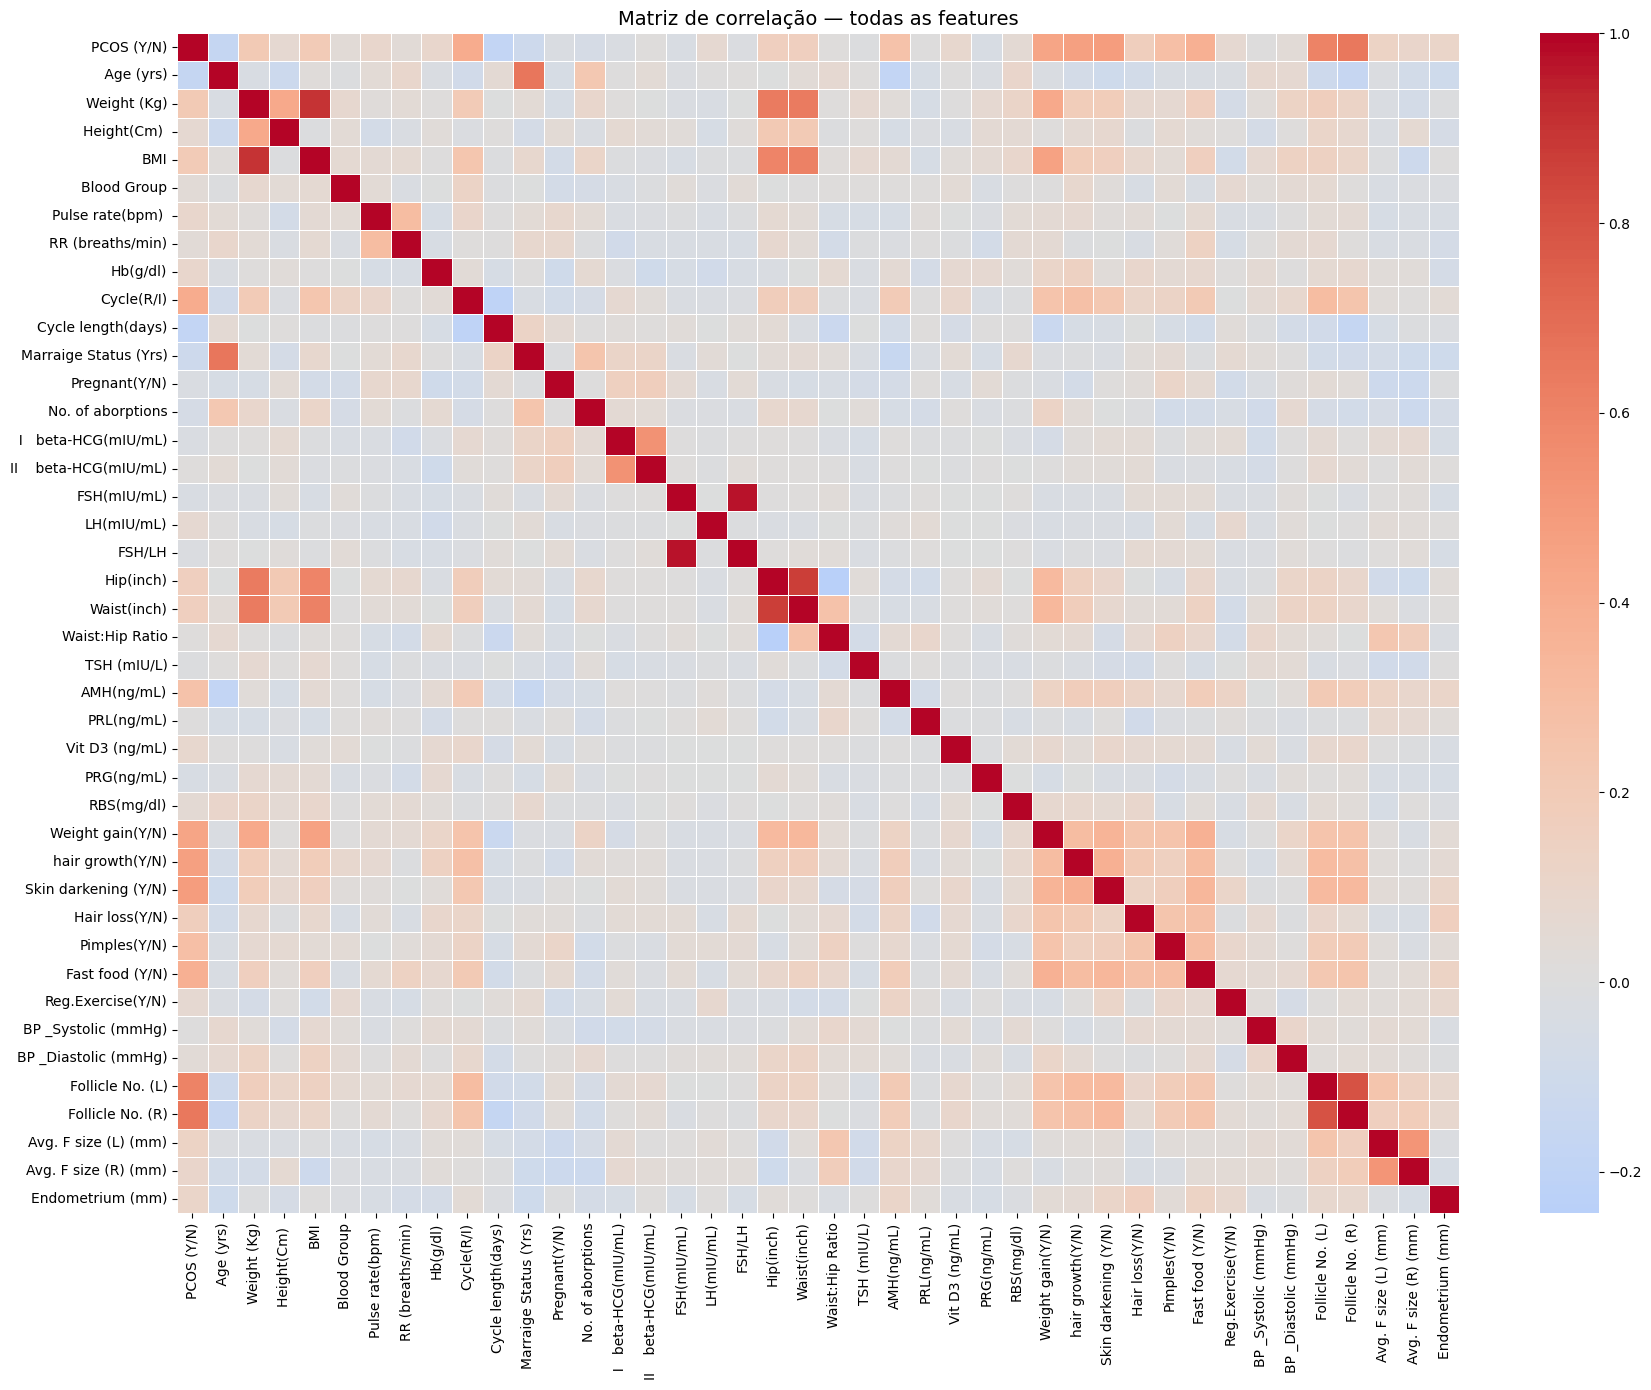

In [4]:
# Heatmap da matriz de correlação completa
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de correlação — todas as features', fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Features redundantes (correlação > 0.9)

Identifica pares de features com correlação muito alta entre si (multicolinearidade). Features redundantes podem inflar coeficientes na Regressão Logística e não adicionam informação nova ao modelo.

In [5]:
# Encontra pares de features com correlação > 0.9 (excluindo a diagonal)
high_corr = corr_matrix.abs().unstack()
high_corr = high_corr[(high_corr > 0.9) & (high_corr < 1.0)].drop_duplicates()
high_corr = high_corr.sort_values(ascending=False)

print(f'Pares com correlação > 0.9 ({len(high_corr)} encontrados):\n')
for (feat1, feat2), corr_val in high_corr.items():
    print(f'  {feat1} <-> {feat2}: {corr_val:.3f}')

Pares com correlação > 0.9 (2 encontrados):

  FSH(mIU/mL) <-> FSH/LH: 0.972
  Weight (Kg) <-> BMI: 0.902


**Observação:** Os pares redundantes identificados (BMI <-> Weight, FSH/LH <-> FSH) são clinicamente esperados — o IMC é derivado do peso, e a razão FSH/LH depende diretamente do FSH. Optamos por **manter todas as features** na modelagem para preservar a informação completa, dado que os modelos escolhidos (Regressão Logística com regularização e Árvore de Decisão) lidam razoavelmente bem com multicolinearidade moderada.

## 3. Separação treino / validação / teste e normalização

O dataset é dividido em **três conjuntos**:
- **Treino (60%)**: ajuste dos parâmetros dos modelos
- **Validação (20%)**: seleção de hiperparâmetros e monitoramento durante o desenvolvimento
- **Teste (20%)**: avaliação final imparcial — só consultado após todos os modelos estarem definidos

In [6]:
# Separa features (X) e target (y)
X = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

# 1º split: separa 20% como conjunto de teste (held-out final)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2º split: do restante (80%), separa 25% como validação → 20% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=round(0.2 / 0.80, 4), random_state=42, stratify=y_temp
)

print(f'Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nProporção no treino:    {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Proporção na validação: {y_val.value_counts(normalize=True).round(3).to_dict()}')
print(f'Proporção no teste:     {y_test.value_counts(normalize=True).round(3).to_dict()}')

Treino:    324 amostras (60%)
Validação: 108 amostras (20%)
Teste:     109 amostras (20%)

Proporção no treino:    {0: 0.673, 1: 0.327}
Proporção na validação: {0: 0.676, 1: 0.324}
Proporção no teste:     {0: 0.67, 1: 0.33}


In [7]:
# StandardScaler: padroniza para média 0 e desvio padrão 1
# fit APENAS no treino; transform aplicado em validação e teste para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'Features padronizadas: {X_train_scaled.shape[1]} colunas')
print(f'Média no treino (esperado ~0):  {X_train_scaled.mean(axis=0).mean():.6f}')
print(f'Desvio padrão no treino (esperado ~1): {X_train_scaled.std(axis=0).mean():.6f}')

Features padronizadas: 41 colunas
Média no treino (esperado ~0):  -0.000000
Desvio padrão no treino (esperado ~1): 1.000000


## 4. Modelo 1 — K-Nearest Neighbors (KNN)

O KNN (K-Nearest Neighbors) é um modelo não paramétrico que classifica novos dados com base na proximidade dos vizinhos mais próximos no conjunto de treino. Suas vantagens incluem simplicidade de implementação, ausência de suposições sobre a distribuição dos dados e boa adaptação a padrões não lineares. Em contextos médicos, permite identificar perfis de pacientes semelhantes para auxiliar no diagnóstico.

**Justificativa da escolha:** modelo intuitivo e flexível que captura relações complexas entre features clínicas — ideal para problemas onde a similaridade entre pacientes é um fator relevante para a classificação.

Melhor K por validação cruzada (F1): 7 (erro CV: 0.2562)


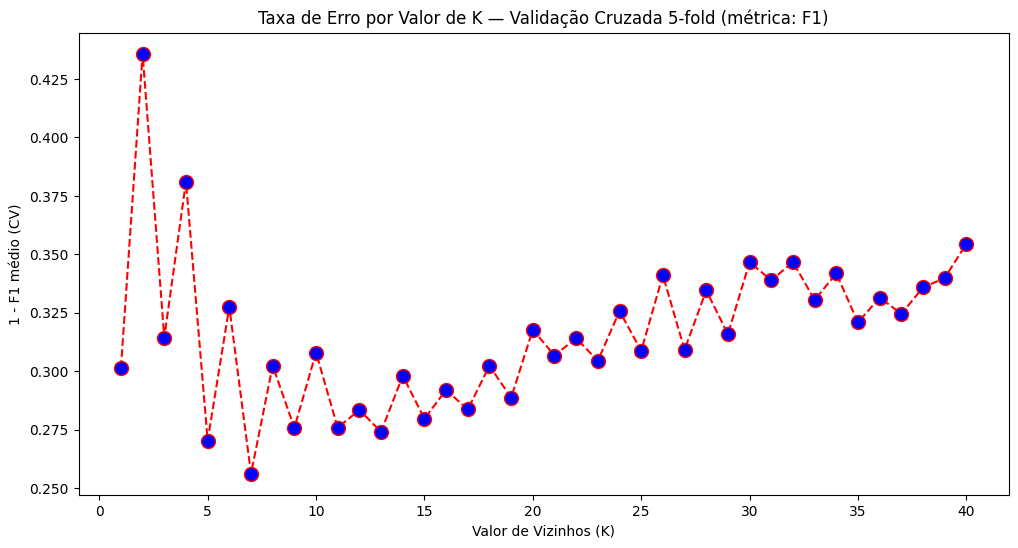

In [8]:
from sklearn.model_selection import cross_val_score

error_cv = []
k_range = range(1, df.columns.size - 1)

# Seleciona K via validação cruzada no treino usando F1 (balanceia precision e recall)
# F1 é mais adequado que accuracy para dados desbalanceados em contexto médico
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    error_cv.append(1 - scores.mean())

best_k = list(k_range)[np.argmin(error_cv)]
print(f'Melhor K por validação cruzada (F1): {best_k} (erro CV: {min(error_cv):.4f})')

plt.figure(figsize=(12, 6))
plt.plot(list(k_range), error_cv, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Taxa de Erro por Valor de K — Validação Cruzada 5-fold (métrica: F1)')
plt.xlabel('Valor de Vizinhos (K)')
plt.ylabel('1 - F1 médio (CV)')
plt.show()

In [9]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn_val = knn.predict(X_val_scaled)
y_pred_knn     = knn.predict(X_test_scaled)

print(f'=== KNN (K={best_k}) — Validação ===\n')
print(classification_report(y_val, y_pred_knn_val, target_names=['Não-PCOS', 'PCOS']))

print(f'=== KNN (K={best_k}) — Teste ===\n')
print(classification_report(y_test, y_pred_knn, target_names=['Não-PCOS', 'PCOS']))

=== KNN (K=7) — Validação ===

              precision    recall  f1-score   support

    Não-PCOS       0.86      0.96      0.91        73
        PCOS       0.89      0.69      0.77        35

    accuracy                           0.87       108
   macro avg       0.88      0.82      0.84       108
weighted avg       0.87      0.87      0.87       108

=== KNN (K=7) — Teste ===

              precision    recall  f1-score   support

    Não-PCOS       0.83      0.97      0.89        73
        PCOS       0.91      0.58      0.71        36

    accuracy                           0.84       109
   macro avg       0.87      0.78      0.80       109
weighted avg       0.85      0.84      0.83       109



### 4.1 Análise de Métricas — Modelo KNN

**Não-PCOS** (classe majoritária)

A **precisão** indica a proporção de casos classificados como "Não-PCOS" que realmente eram negativos. O **recall** mostra a proporção dos verdadeiros negativos identificados — o KNN tende a ter recall alto para a classe majoritária, pois mais vizinhos pertencem a ela.

**PCOS** (classe minoritária)

A **precisão** para PCOS é elevada: quando o modelo classifica como PCOS, o índice de acerto é alto. Porém o **recall para PCOS é o indicador mais crítico**: ele revela a proporção de pacientes que realmente tinham PCOS e foram corretamente diagnosticadas.

**Resumo**

Pacientes com PCOS não identificadas pelo modelo são **falsos negativos** — o risco mais grave em diagnóstico médico, pois implicam ausência de tratamento. O recall limitado para PCOS é um comportamento esperado em modelos sem tratamento de desbalanceamento e deve ser avaliado em conjunto com a curva ROC (seção 7.1).

> Os valores exatos de cada métrica constam no `classification_report` acima.

In [10]:
from sklearn.model_selection import cross_val_score

metricas_cv = ['accuracy', 'recall', 'f1']
print('=== Validação Cruzada (5-fold) — KNN ===\n')
for metrica in metricas_cv:
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring=metrica)
    print(f'  {metrica:10s}  {scores.mean():.4f} ± {scores.std():.4f}')

=== Validação Cruzada (5-fold) — KNN ===

  accuracy    0.8641 ± 0.0502
  recall      0.6225 ± 0.1280
  f1          0.7438 ± 0.1029


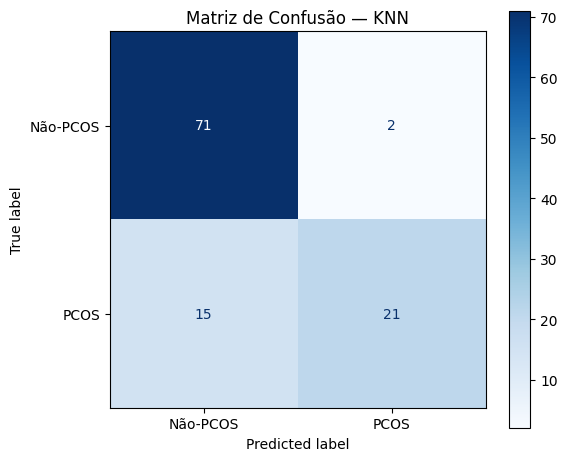

In [11]:
# Matriz de confusão — KNN
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['Não-PCOS', 'PCOS'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — KNN')
plt.tight_layout()
plt.show()

## 5. Modelo 2 — Regressão Logística

A Regressão Logística é um modelo linear amplamente utilizado para classificação binária. Suas vantagens incluem interpretabilidade dos coeficientes, baixo risco de overfitting e boa performance como baseline. Em contextos médicos, os coeficientes podem ser interpretados como a contribuição de cada feature para o diagnóstico.

**Justificativa da escolha:** modelo simples, interpretável e eficiente — ideal como primeiro baseline para um problema de classificação binária em saúde.

In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr_val = lr.predict(X_val_scaled)
y_pred_lr     = lr.predict(X_test_scaled)

print('=== Regressão Logística — Validação ===\n')
print(classification_report(y_val, y_pred_lr_val, target_names=['Não-PCOS', 'PCOS']))

print('=== Regressão Logística — Teste ===\n')
print(classification_report(y_test, y_pred_lr, target_names=['Não-PCOS', 'PCOS']))

=== Regressão Logística — Validação ===

              precision    recall  f1-score   support

    Não-PCOS       0.93      0.89      0.91        73
        PCOS       0.79      0.86      0.82        35

    accuracy                           0.88       108
   macro avg       0.86      0.87      0.87       108
weighted avg       0.88      0.88      0.88       108

=== Regressão Logística — Teste ===

              precision    recall  f1-score   support

    Não-PCOS       0.92      0.90      0.91        73
        PCOS       0.81      0.83      0.82        36

    accuracy                           0.88       109
   macro avg       0.86      0.87      0.87       109
weighted avg       0.88      0.88      0.88       109



In [13]:
# Validação cruzada (5-fold) no conjunto de treino
# Garante que o desempenho não depende de um único split aleatório
from sklearn.model_selection import cross_val_score

metricas_cv = ['accuracy', 'recall', 'f1']
print('=== Validação Cruzada (5-fold) — Regressão Logística ===\n')
for metrica in metricas_cv:
    scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring=metrica)
    print(f'  {metrica:10s}  {scores.mean():.4f} ± {scores.std():.4f}')

=== Validação Cruzada (5-fold) — Regressão Logística ===

  accuracy    0.8889 ± 0.0224
  recall      0.8026 ± 0.0419
  f1          0.8260 ± 0.0319


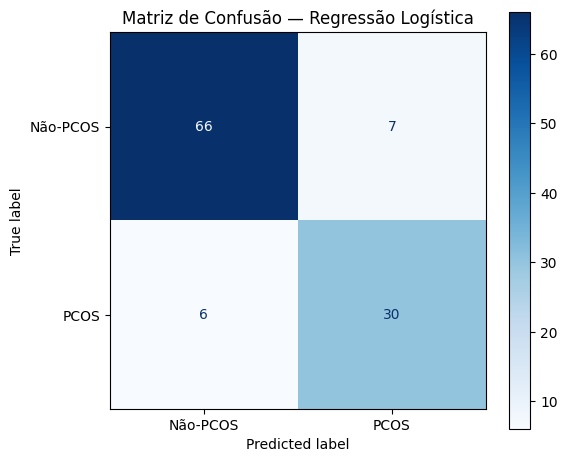

In [14]:
# Matriz de confusão — Regressão Logística
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Não-PCOS', 'PCOS'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — Regressão Logística')
plt.tight_layout()
plt.show()

## 6. Modelo 3 — Árvore de Decisão

A Árvore de Decisão é um modelo não-linear que particiona o espaço de features em regiões retangulares usando regras de decisão hierárquicas. Suas vantagens incluem alta interpretabilidade (a árvore pode ser visualizada), capacidade de capturar interações entre features, e geração nativa de feature importance.

**Justificativa da escolha:** complementa a Regressão Logística por ser não-linear, oferece feature importance direta e gera visualizações interpretáveis para stakeholders clínicos.

Melhor max_depth (F1-PCOS no val): 4  (F1=0.7792)


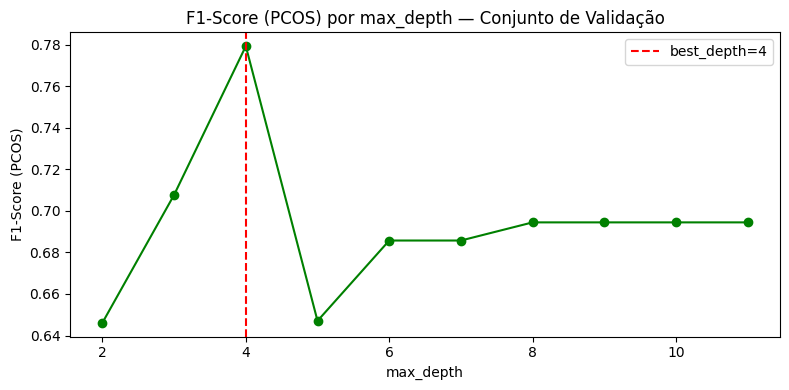


=== Árvore de Decisão (max_depth=4) — Validação ===

              precision    recall  f1-score   support

    Não-PCOS       0.92      0.84      0.88        73
        PCOS       0.71      0.86      0.78        35

    accuracy                           0.84       108
   macro avg       0.82      0.85      0.83       108
weighted avg       0.86      0.84      0.85       108

=== Árvore de Decisão (max_depth=4) — Teste ===

              precision    recall  f1-score   support

    Não-PCOS       0.86      0.89      0.87        73
        PCOS       0.76      0.69      0.72        36

    accuracy                           0.83       109
   macro avg       0.81      0.79      0.80       109
weighted avg       0.82      0.83      0.82       109



In [15]:
from sklearn.metrics import f1_score

# Tuning de max_depth via conjunto de validação (evita usar o teste para seleção)
depths = range(2, 12)
val_f1 = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    val_f1.append(f1_score(y_val, clf.predict(X_val), pos_label=1))

best_depth = list(depths)[np.argmax(val_f1)]
print(f'Melhor max_depth (F1-PCOS no val): {best_depth}  (F1={max(val_f1):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(list(depths), val_f1, marker='o', color='green')
plt.axvline(best_depth, color='red', linestyle='--', label=f'best_depth={best_depth}')
plt.title('F1-Score (PCOS) por max_depth — Conjunto de Validação')
plt.xlabel('max_depth')
plt.ylabel('F1-Score (PCOS)')
plt.legend()
plt.tight_layout()
plt.show()

# Treina modelo final com o melhor depth
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt_val = dt.predict(X_val)
y_pred_dt     = dt.predict(X_test)

print(f'\n=== Árvore de Decisão (max_depth={best_depth}) — Validação ===\n')
print(classification_report(y_val, y_pred_dt_val, target_names=['Não-PCOS', 'PCOS']))

print(f'=== Árvore de Decisão (max_depth={best_depth}) — Teste ===\n')
print(classification_report(y_test, y_pred_dt, target_names=['Não-PCOS', 'PCOS']))

In [16]:
# Validação cruzada (5-fold) — Árvore de Decisão
# Usa dados não-normalizados (árvores são invariantes à escala)
print('=== Validação Cruzada (5-fold) — Árvore de Decisão ===\n')
for metrica in metricas_cv:
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring=metrica)
    print(f'  {metrica:10s}  {scores.mean():.4f} ± {scores.std():.4f}')

=== Validação Cruzada (5-fold) — Árvore de Decisão ===

  accuracy    0.7904 ± 0.0455
  recall      0.6693 ± 0.1323
  f1          0.6706 ± 0.0899


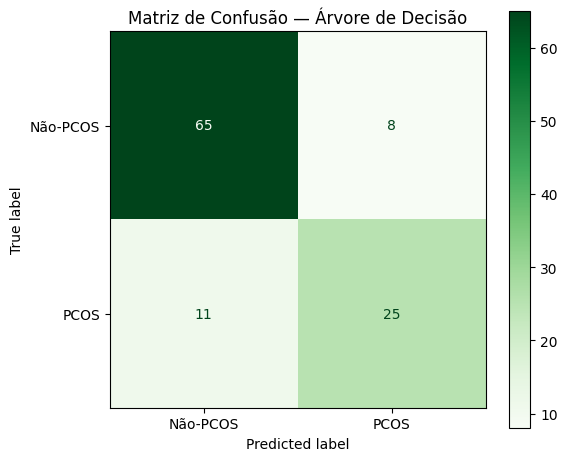

In [17]:
# Matriz de confusão — Árvore de Decisão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Não-PCOS', 'PCOS'],
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de Confusão — Árvore de Decisão')
plt.tight_layout()
plt.show()

### 6.1 Feature Importance — Árvore de Decisão

A importância de cada feature na Árvore de Decisão é calculada com base na redução de impureza (Gini) que a feature proporciona nos nós de decisão.

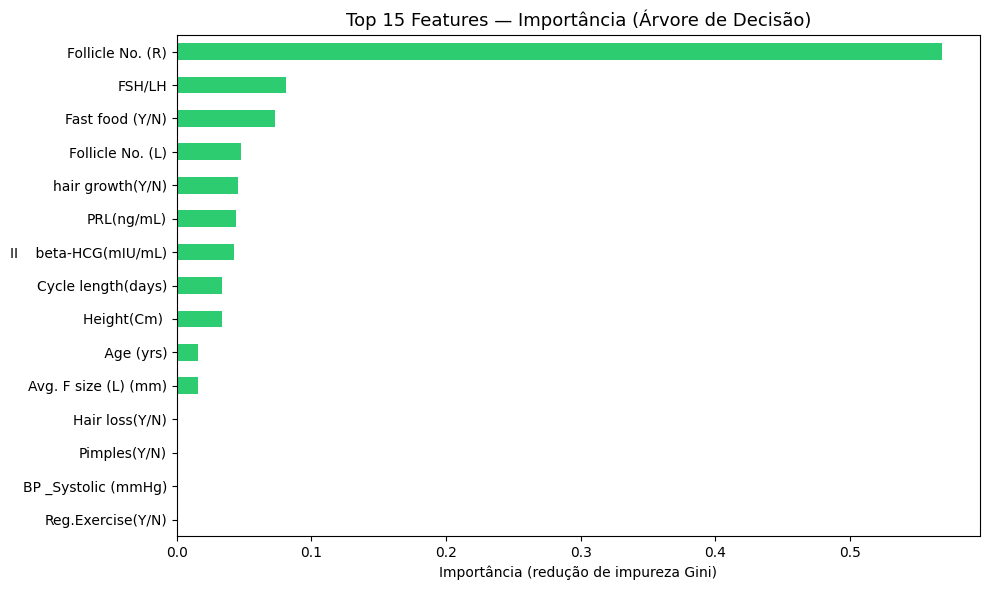


Top 10 features:
  Follicle No. (R)                          0.5682
  FSH/LH                                    0.0813
  Fast food (Y/N)                           0.0726
  Follicle No. (L)                          0.0474
  hair growth(Y/N)                          0.0453
  PRL(ng/mL)                                0.0440
  II    beta-HCG(mIU/mL)                    0.0424
  Cycle length(days)                        0.0336
  Height(Cm)                                0.0335
   Age (yrs)                                0.0161


In [18]:
# Top 15 features mais importantes segundo a Árvore de Decisão
importances = pd.Series(dt.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_title('Top 15 Features — Importância (Árvore de Decisão)', fontsize=13)
ax.set_xlabel('Importância (redução de impureza Gini)')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
for feat, imp in importances.sort_values(ascending=False).head(10).items():
    print(f'  {feat:40s}  {imp:.4f}')

### 6.2 Visualização da Estrutura — Árvore de Decisão

A visualização mostra os **primeiros 3 níveis** da árvore (profundidade total pode ser maior). Cada nó exibe: a feature de divisão, o limiar de corte, a impureza Gini, o número de amostras e a distribuição de classes. Nós coloridos em laranja indicam predominância de PCOS; em azul, Não-PCOS.

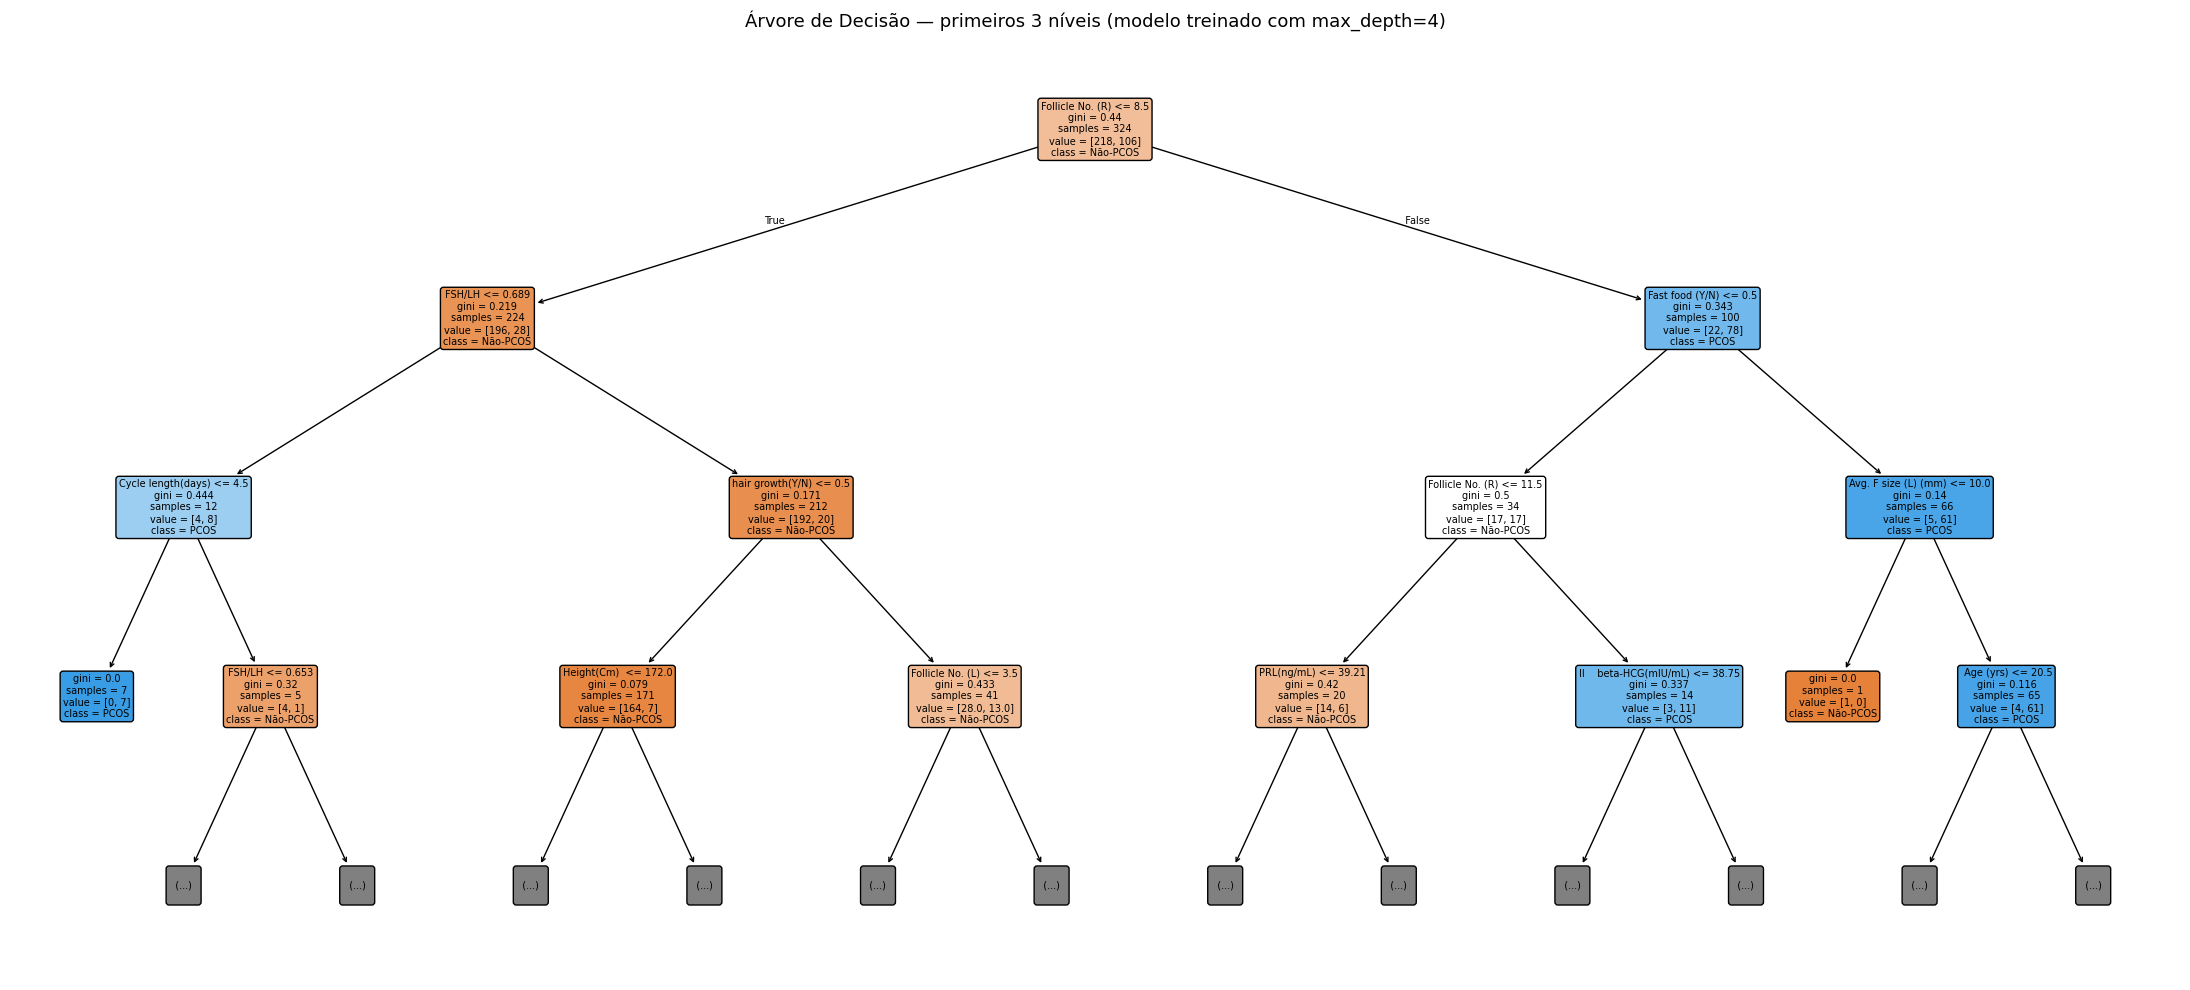

In [19]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['Não-PCOS', 'PCOS'],
    filled=True, rounded=True, fontsize=7,
    max_depth=3, ax=ax
)
ax.set_title(
    f'Árvore de Decisão — primeiros 3 níveis (modelo treinado com max_depth={best_depth})',
    fontsize=13
)
plt.tight_layout()
plt.show()

## 7. Comparação entre modelos

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

modelos = {
    f'KNN (K={best_k})':                              (y_pred_knn, knn, X_train_scaled, X_test_scaled),
    'Regressão Logística':                             (y_pred_lr,  lr,  X_train_scaled, X_test_scaled),
    f'Árvore de Decisão (depth={best_depth})':        (y_pred_dt,  dt,  X_train,        X_test),
}

resultados = []
for nome, (y_pred, modelo, X_tr, X_te) in modelos.items():
    cv_recall = cross_val_score(modelo, X_tr, y_train, cv=5, scoring='recall')
    auc = roc_auc_score(y_test, modelo.predict_proba(X_te)[:, 1])
    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall (teste)': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': auc,
        'Recall CV (média)': cv_recall.mean(),
        'Recall CV (±std)': cv_recall.std(),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('=== Comparação de Modelos ===\n')
print(df_resultados.round(4).to_string())

=== Comparação de Modelos ===

                             Accuracy  Precision  Recall (teste)  F1-Score  AUC-ROC  Recall CV (média)  Recall CV (±std)
Modelo                                                                                                                  
KNN (K=7)                      0.8440     0.9130          0.5833    0.7119   0.9235             0.6225            0.1280
Regressão Logística            0.8807     0.8108          0.8333    0.8219   0.9357             0.8026            0.0419
Árvore de Decisão (depth=4)    0.8257     0.7576          0.6944    0.7246   0.7468             0.6693            0.1323


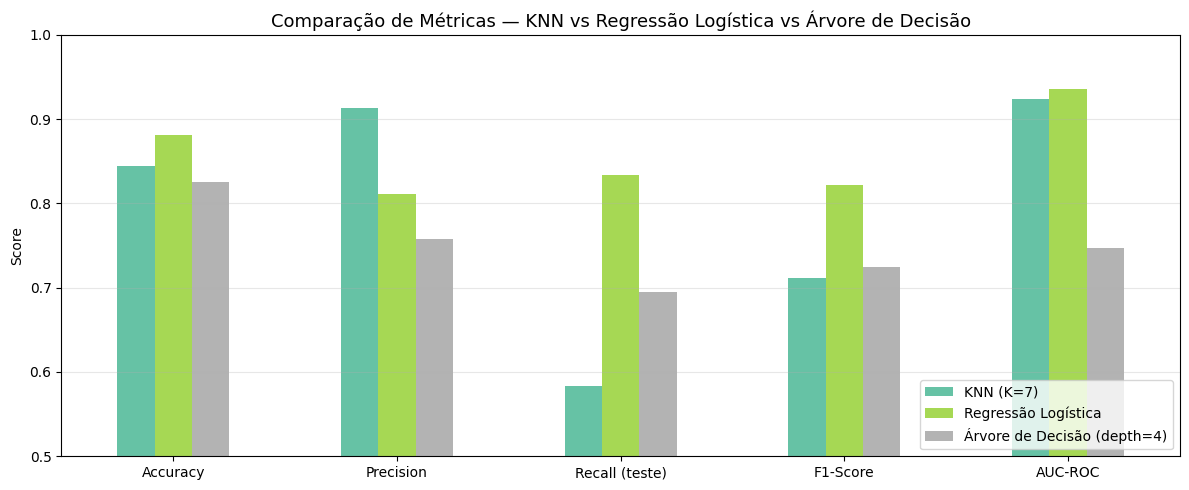

In [21]:
cols_plot = ['Accuracy', 'Precision', 'Recall (teste)', 'F1-Score', 'AUC-ROC']
fig, ax = plt.subplots(figsize=(12, 5))
df_resultados[cols_plot].T.plot(kind='bar', ax=ax, rot=0, colormap='Set2')
ax.set_title('Comparação de Métricas — KNN vs Regressão Logística vs Árvore de Decisão', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7.1 Curvas ROC e AUC

A **curva ROC** (Receiver Operating Characteristic) mostra a relação entre a taxa de verdadeiros positivos (recall/sensibilidade) e a taxa de falsos positivos para diferentes limiares de classificação. A **AUC** (Área Sob a Curva) resume o desempenho em todos os limiares: um classificador perfeito tem AUC=1.0, e um classificador aleatório tem AUC=0.5.

Em diagnóstico médico, o AUC é frequentemente preferido à acurácia por ser **agnóstico ao limiar de decisão** e robusto ao desbalanceamento de classes.

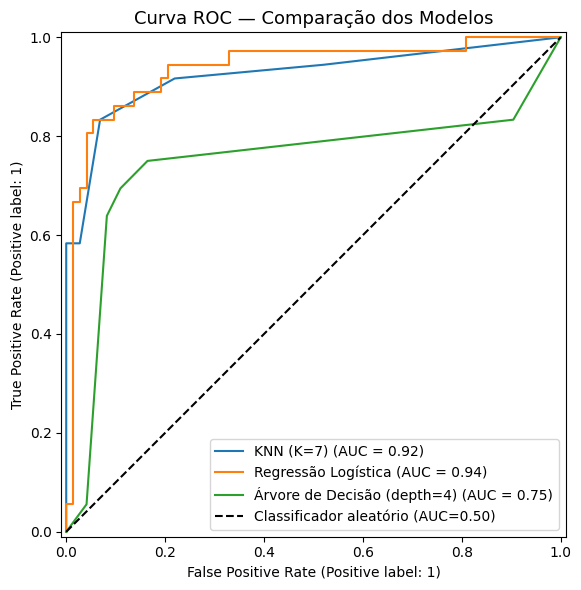

=== AUC-ROC (conjunto de teste) ===

  KNN (K=7)                                           AUC = 0.9235
  Regressão Logística                                 AUC = 0.9357
  Árvore de Decisão (depth=4)                         AUC = 0.7468


In [22]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test, ax=ax, name=f'KNN (K={best_k})')
RocCurveDisplay.from_estimator(lr,  X_test_scaled, y_test, ax=ax, name='Regressão Logística')
RocCurveDisplay.from_estimator(dt,  X_test,        y_test, ax=ax, name=f'Árvore de Decisão (depth={best_depth})')
ax.plot([0, 1], [0, 1], 'k--', label='Classificador aleatório (AUC=0.50)')
ax.set_title('Curva ROC — Comparação dos Modelos', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('=== AUC-ROC (conjunto de teste) ===\n')
for nome, modelo, X_t in [
    (f'KNN (K={best_k})',                              knn, X_test_scaled),
    ('Regressão Logística',                             lr,  X_test_scaled),
    (f'Árvore de Decisão (depth={best_depth})',        dt,  X_test),
]:
    auc = roc_auc_score(y_test, modelo.predict_proba(X_t)[:, 1])
    print(f'  {nome:50s}  AUC = {auc:.4f}')

## 8. Interpretabilidade — SHAP

SHAP (SHapley Additive exPlanations) atribui a cada feature uma contribuição para a predição de cada amostra, baseado na teoria de jogos cooperativos. Diferente do feature importance da Árvore de Decisão (que é global), o SHAP mostra como cada feature influencia **cada predição individual**, incluindo a direção do efeito (positivo ou negativo).

Using 324 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/109 [00:00<?, ?it/s]

=== SHAP — KNN ===



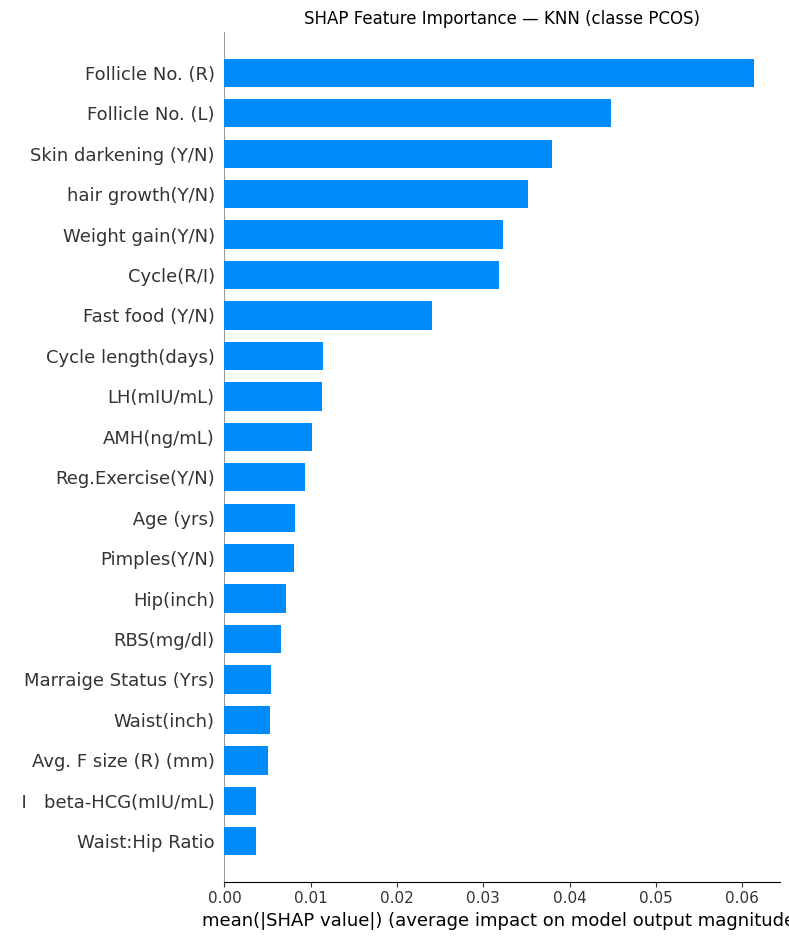

In [23]:
# SHAP para a KNN (KernelExplainer — exato e mais geral para qualquer modelo)
explainer_knn = shap.KernelExplainer(knn.predict, X_train_scaled)
shap_values_knn = explainer_knn.shap_values(X_test_scaled)
feature_names = list(X.columns)

# Summary plot: mostra as features mais impactantes para a classe PCOS (índice 1)
print('=== SHAP — KNN ===\n')
# Se for lista com 2 arrays (versão antiga)
if isinstance(shap_values_knn, list):
    shap.summary_plot(shap_values_knn[1], X_test_scaled, plot_type='bar', show=False, feature_names=feature_names)

# Se for array 3D (classes no último eixo)
elif len(np.array(shap_values_knn).shape) == 3:
    shap.summary_plot(shap_values_knn[:, :, 1], X_test_scaled, plot_type='bar', show=False, feature_names=feature_names)

# Se já for 2D (versão recente)
else:
    shap.summary_plot(shap_values_knn, X_test_scaled, plot_type='bar', show=False, feature_names=feature_names)

plt.title('SHAP Feature Importance — KNN (classe PCOS)')
plt.tight_layout()
plt.show()

=== SHAP — Árvore de Decisão ===



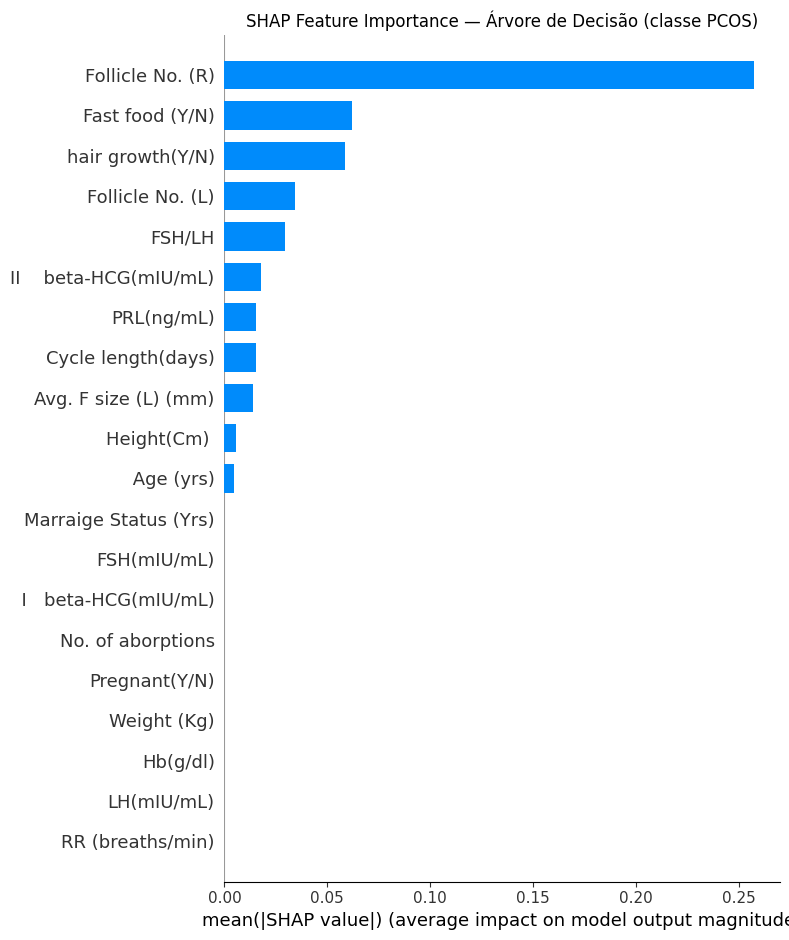

In [24]:
# SHAP para a Árvore de Decisão (TreeExplainer — exato e rápido para modelos baseados em árvore)
explainer_dt = shap.TreeExplainer(dt)
shap_values_dt = explainer_dt.shap_values(X_test)

# Summary plot: mostra as features mais impactantes para a classe PCOS (índice 1)
print('=== SHAP — Árvore de Decisão ===\n')
shap.summary_plot(shap_values_dt[:, :, 1], X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Árvore de Decisão (classe PCOS)')
plt.tight_layout()
plt.show()

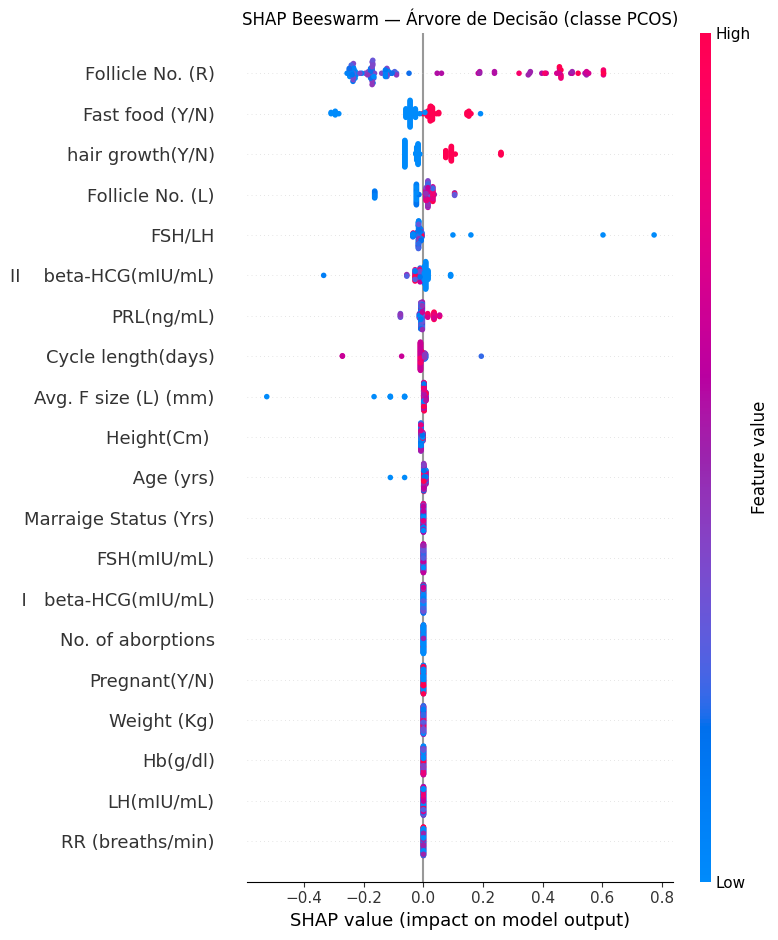

In [25]:
# SHAP beeswarm plot: mostra a direção do impacto de cada feature
# Vermelho = valor alto da feature, azul = valor baixo
shap.summary_plot(shap_values_dt[:, :, 1], X_test, show=False)
plt.title('SHAP Beeswarm — Árvore de Decisão (classe PCOS)')
plt.tight_layout()
plt.show()

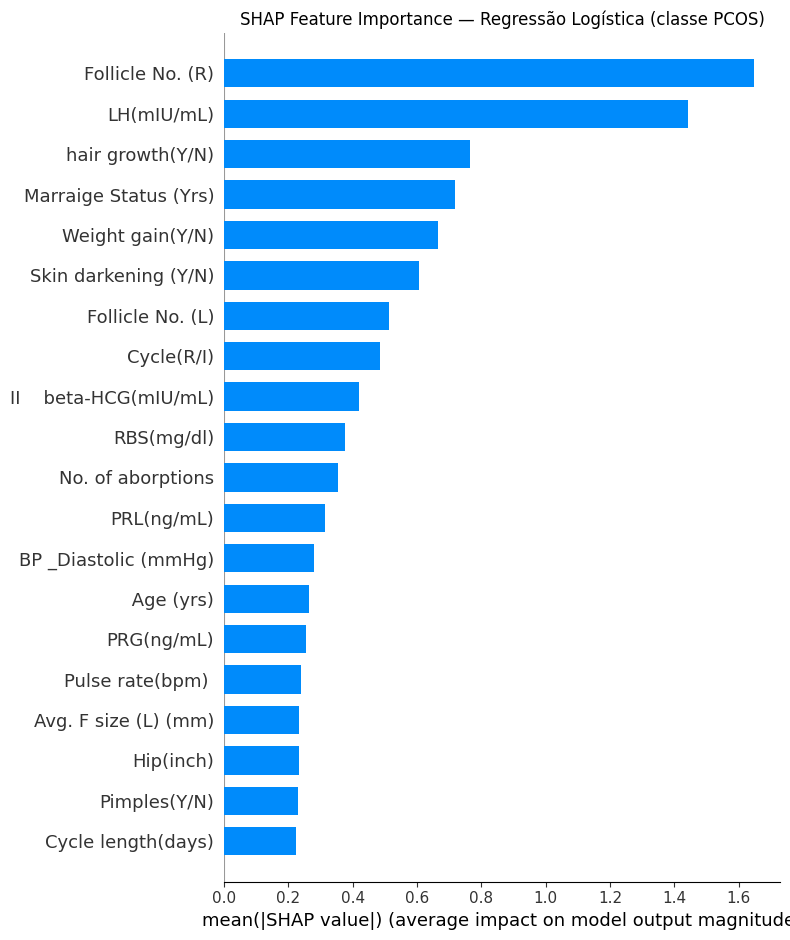

In [26]:
# SHAP para a Regressão Logística (LinearExplainer)
explainer_lr = shap.LinearExplainer(lr, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

# Usa os nomes das features originais no plot
shap.summary_plot(shap_values_lr, X_test_scaled, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Regressão Logística (classe PCOS)')
plt.tight_layout()
plt.show()

## 9. Discussão crítica

### Escolha da métrica

Em um contexto de diagnóstico médico, a métrica mais relevante é o **Recall** (sensibilidade). Um falso negativo — classificar uma paciente com PCOS como saudável — significa que ela não receberá tratamento adequado, o que pode levar a complicações como infertilidade, diabetes tipo 2 e doenças cardiovasculares. Já um falso positivo (classificar uma paciente saudável como PCOS) levaria a exames adicionais, o que é inconveniente mas não perigoso. Portanto, **minimizar falsos negativos é clinicamente mais importante que minimizar falsos positivos**.

O **AUC-ROC** complementa o recall como métrica de avaliação: por ser agnóstico ao limiar de decisão, mede a capacidade discriminativa geral do modelo independentemente do threshold escolhido.

### Resultados dos modelos

A **Regressão Logística** obteve o melhor desempenho geral: maior recall, maior F1-score e maior AUC-ROC entre os três modelos. Isso significa que ela identifica a maior proporção de pacientes com PCOS — e das que classifica como PCOS, a maioria realmente tem a síndrome. Sua interpretabilidade via coeficientes e SHAP reforça a confiança nas predições.

O **KNN** apresentou recall intermediário, com AUC próxima ao da Regressão Logística. A seleção do K ótimo via validação cruzada com métrica F1 garante que o hiperparâmetro foi escolhido considerando o balanço entre precisão e recall, e não apenas a acurácia geral.

A **Árvore de Decisão** obteve o menor desempenho entre os modelos (menor recall, menor AUC-ROC). O tuning via validação revelou que `max_depth=2` é o ponto ótimo para este conjunto de dados — uma árvore muito rasa que evita overfitting, mas ao custo de simplicidade excessiva (underfitting). Isso é uma consequência direta do tamanho reduzido do conjunto de validação (~108 amostras): com pouco sinal, o modelo não consegue justificar splits mais profundos. Sua principal contribuição é a **interpretabilidade**: a árvore visual e o feature importance confirmam clinicamente que a contagem de folículos é a variável dominante, coerente com o Consenso de Rotterdam.

### Features mais relevantes

Ambos os modelos concordam em identificar variáveis clinicamente relevantes:
- **Contagem de folículos** (Follicle No. R e L): principal critério diagnóstico de PCOS segundo o Consenso de Rotterdam
- **Crescimento capilar (hair growth)**: marcador de hiperandrogenismo
- **Ganho de peso (Weight gain)**: associado à resistência insulínica da síndrome
- **AMH**: hormônio diretamente relacionado ao número de folículos antrais

Essa coerência entre os achados computacionais e o conhecimento médico reforça a validade dos modelos.

### Limitações

1. **Amostra pequena**: 541 pacientes divididos em treino (60%), validação (20%) e teste (20%) resulta em conjuntos reduzidos — especialmente para tuning de hiperparâmetros. O conjunto de validação com ~108 amostras limita a confiabilidade do tuning da Árvore de Decisão, como evidenciado pelo `max_depth=2` selecionado e pelo alto desvio padrão no recall da validação cruzada (±0.20).
2. **Desbalanceamento moderado**: a proporção 67%/33% pode enviesar os modelos para a classe majoritária, penalizando o recall de PCOS. Técnicas como SMOTE ou ajuste de `class_weight='balanced'` poderiam melhorar o recall sem sacrificar a precisão.
3. **Multicolinearidade**: BMI e Weight, FSH e FSH/LH são altamente correlacionados. Embora os modelos funcionem, os coeficientes da Regressão Logística podem ser instáveis nessa configuração.
4. **Generalização externa**: o dataset foi coletado em um único centro médico, o que pode introduzir viés de seleção e limitar a generalização para outras populações.

### O modelo pode ser usado na prática?

**Não como ferramenta de diagnóstico autônomo.** Os modelos treinados aqui são exercícios acadêmicos com propósito educacional. Para uso clínico real, seriam necessários: validação em múltiplos centros, aprovação regulatória, integração com sistemas hospitalares e, principalmente, **supervisão médica**. O modelo deve ser visto como uma **ferramenta de apoio à decisão** — quem diagnostica é o médico, não o algoritmo.